In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

In [3]:
df = pd.read_csv("../data/customer_churn_cleaned.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
# Binary encoding

binary_map = {
    "Yes": 1,
    "No": 0,
    "Female": 0,
    "Male": 1
}

binary_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for col in binary_features:
    X[col] = X[col].map(binary_map)

In [6]:
# Encode target

y = y.map({
    "No": 0,
    "Yes": 1
})

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
categorical_features = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [12]:
lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [13]:
lr_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
type(lr_model)

sklearn.pipeline.Pipeline

In [15]:
print(X_train.shape)
print(X_test.shape)

(5608, 19)
(1402, 19)


In [16]:
result = permutation_importance(
    lr_model,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

In [17]:
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
4,tenure,0.117047
7,InternetService,0.035949
18,TotalCharges,0.030813
14,Contract,0.026534
15,PaperlessBilling,0.009986
17,MonthlyCharges,0.007846
16,PaymentMethod,0.006847
6,MultipleLines,0.005991
12,StreamingTV,0.005421
13,StreamingMovies,0.004850


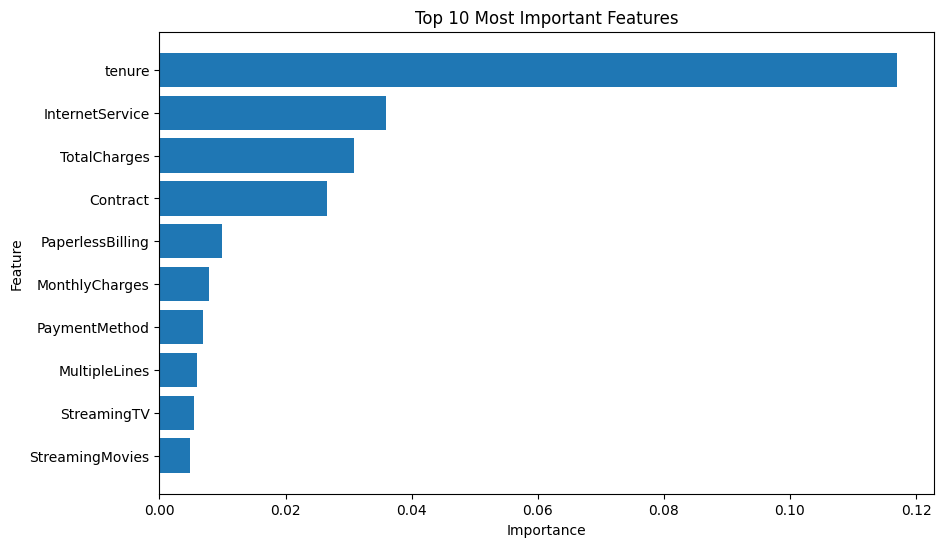

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [19]:
contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.722826,11.277174
Two year,97.151335,2.848665


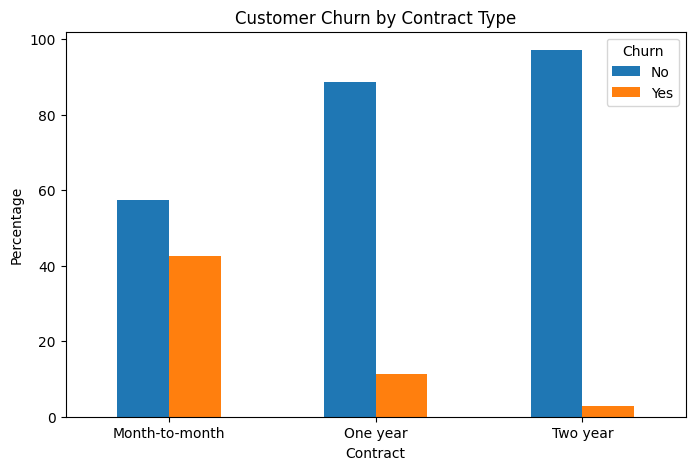

In [20]:
contract.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [21]:
internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet

Churn,No,Yes
InternetService,,
DSL,81.068766,18.931234
Fiber optic,58.220065,41.779935
No,92.762284,7.237716


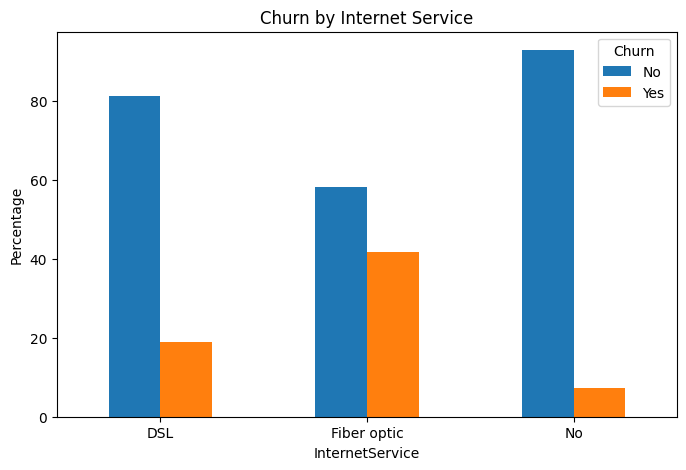

In [22]:
internet.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn by Internet Service")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

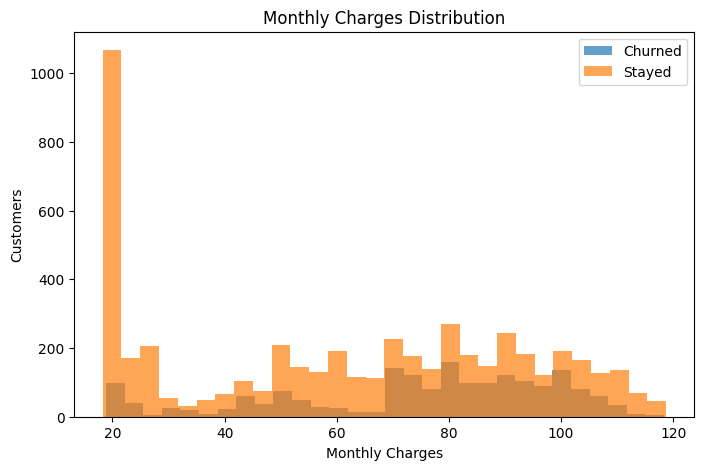

In [23]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn"]=="Yes"]["MonthlyCharges"],
    alpha=0.7,
    bins=30,
    label="Churned"
)

plt.hist(
    df[df["Churn"]=="No"]["MonthlyCharges"],
    alpha=0.7,
    bins=30,
    label="Stayed"
)

plt.legend()

plt.xlabel("Monthly Charges")

plt.ylabel("Customers")

plt.title("Monthly Charges Distribution")

plt.show()

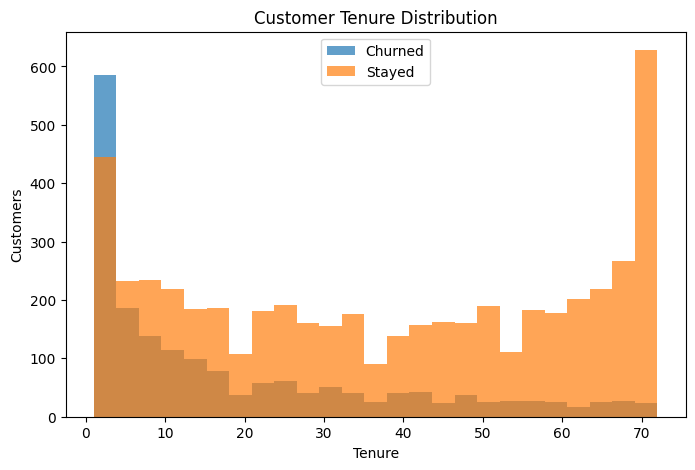

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn"]=="Yes"]["tenure"],
    bins=25,
    alpha=0.7,
    label="Churned"
)

plt.hist(
    df[df["Churn"]=="No"]["tenure"],
    bins=25,
    alpha=0.7,
    label="Stayed"
)

plt.legend()

plt.xlabel("Tenure")

plt.ylabel("Customers")

plt.title("Customer Tenure Distribution")

plt.show()

Business Insights
1. Contract Type Strongly Influences Churn

Customers on month-to-month contracts exhibit the highest churn rates, while those on one-year and two-year contracts are much more likely to remain with the company. Encouraging long-term contracts could significantly reduce customer attrition.

2. Customers with Short Tenure Are More Likely to Churn

New customers are at greater risk of leaving during the early months of service. Targeted onboarding programs and early engagement initiatives could improve customer retention.

3. Higher Monthly Charges Increase Churn Risk

Customers paying higher monthly fees tend to churn more frequently. Promotional discounts, personalized pricing, or bundled service packages may help improve customer satisfaction and loyalty.

4. Fiber Optic Customers Have Higher Churn Rates

Despite offering faster internet service, fiber optic customers show a higher likelihood of churning. This may indicate issues related to pricing, service quality, or customer expectations that require further investigation.

5. Customer Support Services Matter

Customers without services such as online security, technical support, or device protection are more likely to churn. Promoting value-added services could enhance customer retention.

Conclusion

Five machine learning models were developed and evaluated for predicting customer churn: Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), and XGBoost.

Among these models, Logistic Regression achieved the highest accuracy of approximately 80.8%, making it the best-performing model for this dataset. The analysis identified several key drivers of customer churn, including contract type, customer tenure, monthly charges, internet service type, and the availability of support-related services.

The results demonstrate that machine learning can effectively identify customers at high risk of churn, enabling businesses to implement targeted retention strategies, reduce customer attrition, and improve long-term profitability.